# COVID EMA Analysis
This notebook profiles the COVID EMA file and determines its role in the pipeline.
The file contains 10 survey items measuring COVID-19 concern, impact, behavior change, and social support collected during the pandemic period only.

In [11]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [12]:
# Paths
GENERAL_EMA_PATH = "../../data/raw/college_experience_dataset/EMA/general_ema.csv"
COVID_EMA_PATH   = "../../data/raw/college_experience_dataset/EMA/covid_ema.csv"

# COVID item columns
COVID_ITEMS = [f"COVID-{i}" for i in range(1, 11)]

# Directionality reference
COVID_DIRECTIONS = {
    "COVID-1":  "negative",   # concerned about COVID generally
    "COVID-2":  "negative",   # daily life impacted
    "COVID-3":  "negative",   # behavior changed
    "COVID-4":  "negative",   # concerned for self
    "COVID-5":  "negative",   # concerned for classmates
    "COVID-6":  "negative",   # concerned for family
    "COVID-7":  "negative",   # concerned about supplies
    "COVID-8":  "positive",   # feels supported
    "COVID-9":  "ambiguous",  # has supported others
    "COVID-10": "ambiguous",  # social media usage change
}

EXCLUDE_UIDS = [
    "df5e798581def8d477316520953b9171",   
    "e6d71fe4a3c10b075ae1cf51a2fe6cfd",   
    "ea716dd032aaa0dcf8bfa36b1811917f",   
    "ad15fc229da933fbf1fc0f92fc9b55a3",  
]

In [13]:
def load_covid_ema(path: str) -> pd.DataFrame:
    df = pd.read_csv(path)
    df["date"] = pd.to_datetime(df["day"].astype(str), format="%Y%m%d")
    df["year_week"] = (
        df["date"].dt.isocalendar().year.astype(str) + "-W" +
        df["date"].dt.isocalendar().week.astype(str).str.zfill(2)
    )
    return df

df_covid = load_covid_ema(COVID_EMA_PATH)

print(f"Shape       : {df_covid.shape[0]:,} rows x {df_covid.shape[1]} columns")
print(f"Columns     : {list(df_covid.columns)}")
print(f"Students    : {df_covid['uid'].nunique()}")
print(f"\nFirst 5 rows:")
print(df_covid.head())

Shape       : 16,511 rows x 14 columns
Columns     : ['uid', 'day', 'COVID-1', 'COVID-2', 'COVID-3', 'COVID-4', 'COVID-5', 'COVID-6', 'COVID-7', 'COVID-8', 'COVID-9', 'COVID-10', 'date', 'year_week']
Students    : 181

First 5 rows:
                                uid       day  COVID-1  COVID-2  COVID-3  \
0  1ff6d7f34acb354430e7323a35ff7703  20200317      NaN      NaN      NaN   
1  1ff6d7f34acb354430e7323a35ff7703  20200320      5.0      7.0      6.0   
2  1ff6d7f34acb354430e7323a35ff7703  20200327      6.0      5.0      5.0   
3  1ff6d7f34acb354430e7323a35ff7703  20200331      3.0      6.0      4.0   
4  1ff6d7f34acb354430e7323a35ff7703  20200410      3.0      4.0      4.0   

   COVID-4  COVID-5  COVID-6  COVID-7  COVID-8  COVID-9  COVID-10       date  \
0      NaN      NaN      NaN      NaN      NaN      NaN       NaN 2020-03-17   
1      6.0      4.0      6.0      4.0      2.0      3.0       4.0 2020-03-20   
2      4.0      3.0      5.0      3.0      3.0      3.0       4.0 2020

In [14]:
# Same three-state classification as general_ema
df_covid["has_response"] = df_covid[COVID_ITEMS].notna().any(axis=1)

# No separate timing columns in this file - incomplete detection via partial fills
df_covid["partial_response"] = (
    df_covid[COVID_ITEMS].notna().any(axis=1) &
    df_covid[COVID_ITEMS].isna().any(axis=1)
)
df_covid["full_response"] = df_covid[COVID_ITEMS].notna().all(axis=1)
df_covid["no_response"]   = ~df_covid["has_response"]

print("Row classification:")
print(f"  Full responses (all 10 items)    : {df_covid['full_response'].sum():,}")
print(f"  Partial responses (some items)   : {df_covid['partial_response'].sum():,}")
print(f"  No response                      : {df_covid['no_response'].sum():,}")
print(f"  Total rows                       : {len(df_covid):,}")

Row classification:
  Full responses (all 10 items)    : 5,614
  Partial responses (some items)   : 0
  No response                      : 10,897
  Total rows                       : 16,511


### Temporal Coverage

Checking the date range of COVID EMA data. Expected to start in March 2020 and finish in May 2022.

In [15]:
completed = df_covid[df_covid["has_response"]]

global_start = completed["date"].min()
global_end   = completed["date"].max()
total_days   = (global_end - global_start).days + 1
total_weeks  = round(total_days / 7, 1)

print(f"COVID EMA temporal coverage (completed responses only):")
print(f"  First response : {global_start.date()}")
print(f"  Last response  : {global_end.date()}")
print(f"  Calendar days  : {total_days}")
print(f"  Calendar weeks : {total_weeks}")

# Per-student date range
per_student = (
    completed.groupby("uid")["date"]
    .agg(start="min", end="max")
    .assign(span_days=lambda x: (x["end"] - x["start"]).dt.days + 1)
)

print(f"\nPer-student span summary:")
print(per_student["span_days"].describe().round(1))
print(f"\nEarliest start dates (top 5):")
print(per_student.nsmallest(5, "start")[["start", "end", "span_days"]])
print(f"\nLatest end dates (top 5):")
print(per_student.nlargest(5, "end")[["start", "end", "span_days"]])

COVID EMA temporal coverage (completed responses only):
  First response : 2020-03-18
  Last response  : 2022-04-23
  Calendar days  : 767
  Calendar weeks : 109.6

Per-student span summary:
count    180.0
mean     399.8
std      235.6
min        1.0
25%      227.5
50%      423.0
75%      598.0
max      767.0
Name: span_days, dtype: float64

Earliest start dates (top 5):
                                      start        end  span_days
uid                                                              
0107c61e54459068bb83f6be2058d65d 2020-03-18 2021-12-25        648
03a0ce5623bfeb8aa3113605f7682215 2020-03-18 2022-04-23        767
0947cdc8e87a0a45a012aa387ccedbcd 2020-03-18 2022-03-12        725
0ba15aa0582c5e825710d42fe3eb231d 2020-03-18 2021-04-10        389
284784fd7319c4e33b0bf1dc90c1a610 2020-03-18 2021-03-20        368

Latest end dates (top 5):
                                      start        end  span_days
uid                                                              
03a0c

### Student Overlap with general_ema

How many of the 217 students from the cleaned general_ema dataset appear in the COVID EMA file? 

In [16]:
def load_general_ema(path: str) -> pd.DataFrame:
    df = pd.read_csv(path)
    df["date"] = pd.to_datetime(df["day"].astype(str), format="%Y%m%d")
    df["year_week"] = (
        df["date"].dt.isocalendar().year.astype(str) + "-W" +
        df["date"].dt.isocalendar().week.astype(str).str.zfill(2)
    )
    return df

df_general = load_general_ema(GENERAL_EMA_PATH)
df_general_clean = df_general[~df_general["uid"].isin(EXCLUDE_UIDS)].copy()

general_uids = set(df_general_clean["uid"].unique())
covid_uids   = set(df_covid[df_covid["has_response"]]["uid"].unique())

overlap      = general_uids & covid_uids
only_general = general_uids - covid_uids
only_covid   = covid_uids - general_uids

print(f"Students in general_ema (clean)  : {len(general_uids)}")
print(f"Students in covid_ema            : {len(covid_uids)}")
print(f"Students in both                 : {len(overlap)}")
print(f"Only in general_ema              : {len(only_general)}")
print(f"Only in covid_ema                : {len(only_covid)}")
print(f"\nOverlap rate                     : {len(overlap)/len(general_uids)*100:.1f}%")

if only_covid:
    print(f"\nUIDs in covid_ema but not general_ema:")
    for uid in only_covid:
        print(f"  {uid}")

Students in general_ema (clean)  : 216
Students in covid_ema            : 180
Students in both                 : 180
Only in general_ema              : 36
Only in covid_ema                : 0

Overlap rate                     : 83.3%


### Survey Frequency and Missingness

How often did students complete COVID surveys? 

In [17]:
# Per-student total responses
per_student_counts = (
    df_covid[df_covid["has_response"]]
    .groupby("uid")
    .size()
    .reset_index(name="total_covid_surveys")
    .sort_values("total_covid_surveys", ascending=False)
)

print("Per-student COVID survey count summary:")
print(per_student_counts["total_covid_surveys"].describe().round(1))

# Weekly density
covid_weekly = (
    df_covid[df_covid["has_response"]]
    .groupby(["uid", "year_week"])
    .size()
    .reset_index(name="surveys_in_week")
)

dist = (
    covid_weekly["surveys_in_week"]
    .value_counts()
    .sort_index()
    .reset_index()
)
dist.columns = ["surveys_in_week", "count"]
dist["pct"] = (dist["count"] / dist["count"].sum() * 100).round(2)

print(f"\nWeekly survey distribution:")
print(dist.to_string(index=False))
print(f"\nTotal (student, week) pairs : {len(covid_weekly):,}")
print(f"Mean surveys per pair       : {covid_weekly['surveys_in_week'].mean():.2f}")

# Item-level missingness
print(f"\nItem-level missingness across all rows:")
for col in COVID_ITEMS:
    n_null = df_covid[col].isna().sum()
    pct    = n_null / len(df_covid) * 100
    print(f"  {col}: {n_null:,} missing ({pct:.1f}%)")

Per-student COVID survey count summary:
count    180.0
mean      31.2
std       25.6
min        1.0
25%       10.0
50%       23.0
75%       48.0
max      113.0
Name: total_covid_surveys, dtype: float64

Weekly survey distribution:
 surveys_in_week  count   pct
               1   5021 94.95
               2    215  4.07
               3     45  0.85
               4      7  0.13

Total (student, week) pairs : 5,288
Mean surveys per pair       : 1.06

Item-level missingness across all rows:
  COVID-1: 10,897 missing (66.0%)
  COVID-2: 10,897 missing (66.0%)
  COVID-3: 10,897 missing (66.0%)
  COVID-4: 10,897 missing (66.0%)
  COVID-5: 10,897 missing (66.0%)
  COVID-6: 10,897 missing (66.0%)
  COVID-7: 10,897 missing (66.0%)
  COVID-8: 10,897 missing (66.0%)
  COVID-9: 10,897 missing (66.0%)
  COVID-10: 10,897 missing (66.0%)


### Item Distributions

Distribution of each COVID item across all completed responses.
Items with very low variance (everyone scoring at the same level) carry
little predictive signal and are weak feature candidates.
All items use a 1-7 scale.

Produces a score distribution diagram in output/figures.

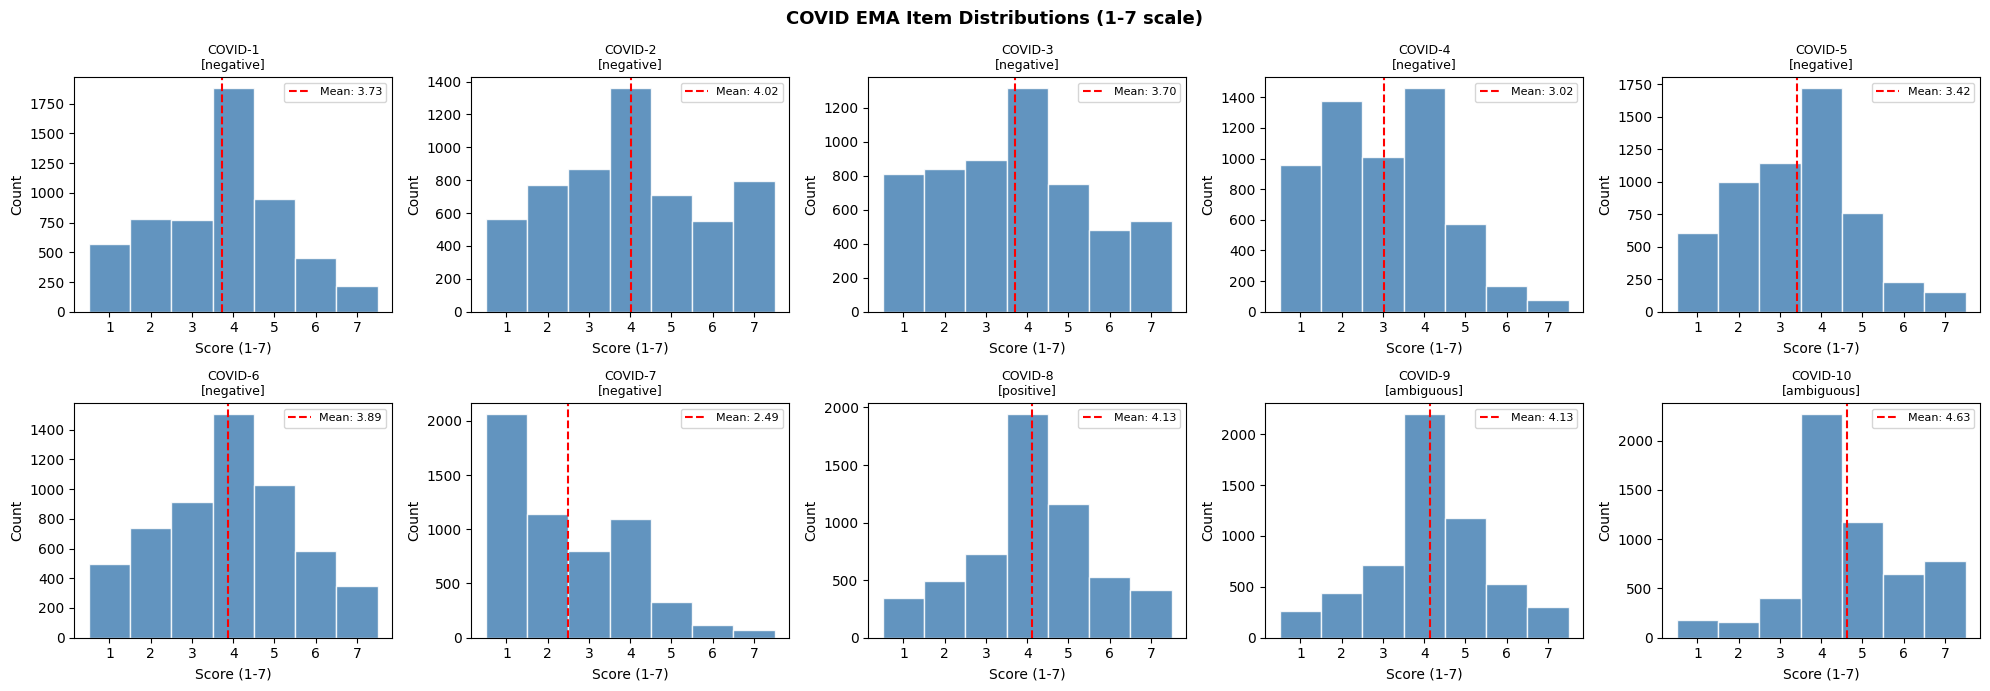

Descriptive statistics per item:
        COVID-1   COVID-2   COVID-3   COVID-4   COVID-5   COVID-6   COVID-7  \
count  5614.000  5614.000  5614.000  5614.000  5614.000  5614.000  5614.000   
mean      3.725     4.019     3.701     3.021     3.416     3.885     2.490   
std       1.537     1.844     1.816     1.440     1.446     1.623     1.495   
min       1.000     1.000     1.000     1.000     1.000     1.000     1.000   
25%       3.000     3.000     2.000     2.000     2.000     3.000     1.000   
50%       4.000     4.000     4.000     3.000     4.000     4.000     2.000   
75%       5.000     5.000     5.000     4.000     4.000     5.000     4.000   
max       7.000     7.000     7.000     7.000     7.000     7.000     7.000   

        COVID-8   COVID-9  COVID-10  
count  5614.000  5614.000  5614.000  
mean      4.125     4.131     4.629  
std       1.508     1.383     1.416  
min       1.000     1.000     1.000  
25%       3.000     3.000     4.000  
50%       4.000     4.000  

In [18]:
completed_covid = df_covid[df_covid["has_response"]].copy()

fig, axes = plt.subplots(2, 5, figsize=(20, 7))
axes = axes.flatten()

for i, col in enumerate(COVID_ITEMS):
    data = completed_covid[col].dropna()
    direction = COVID_DIRECTIONS[col]
    axes[i].hist(data, bins=7, range=(0.5, 7.5),
                 color="steelblue", edgecolor="white", alpha=0.85)
    axes[i].axvline(data.mean(), color="red", linestyle="--",
                    linewidth=1.5, label=f"Mean: {data.mean():.2f}")
    axes[i].set_title(f"{col}\n[{direction}]", fontsize=9)
    axes[i].set_xlabel("Score (1-7)")
    axes[i].set_ylabel("Count")
    axes[i].set_xticks(range(1, 8))
    axes[i].legend(fontsize=8)

plt.suptitle("COVID EMA Item Distributions (1-7 scale)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("../../outputs/figures/covid_ema_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

print("Descriptive statistics per item:")
print(completed_covid[COVID_ITEMS].describe().round(3))

### Correlation with General EMA Mental Health Scores

For weeks where a student completed both a COVID survey and a general_ema survey, what is the correlation between COVID items and mental health scores (PHQ4, stress, composite)?

Produces a COVID vs mental health correlation diagram in output/figures.

Weeks with both general_ema and COVID EMA responses: 4,729
Students represented in overlap                    : 180

Correlation between COVID items and mental health scores:
          phq4_score  stress  composite_score
COVID-1        0.221   0.209           -0.223
COVID-2        0.170   0.121           -0.152
COVID-3        0.084   0.068           -0.070
COVID-4        0.058   0.140           -0.111
COVID-5        0.180   0.183           -0.183
COVID-6        0.195   0.168           -0.179
COVID-7        0.105   0.136           -0.108
COVID-8       -0.243  -0.127            0.242
COVID-9        0.026   0.066            0.013
COVID-10       0.154   0.118           -0.147


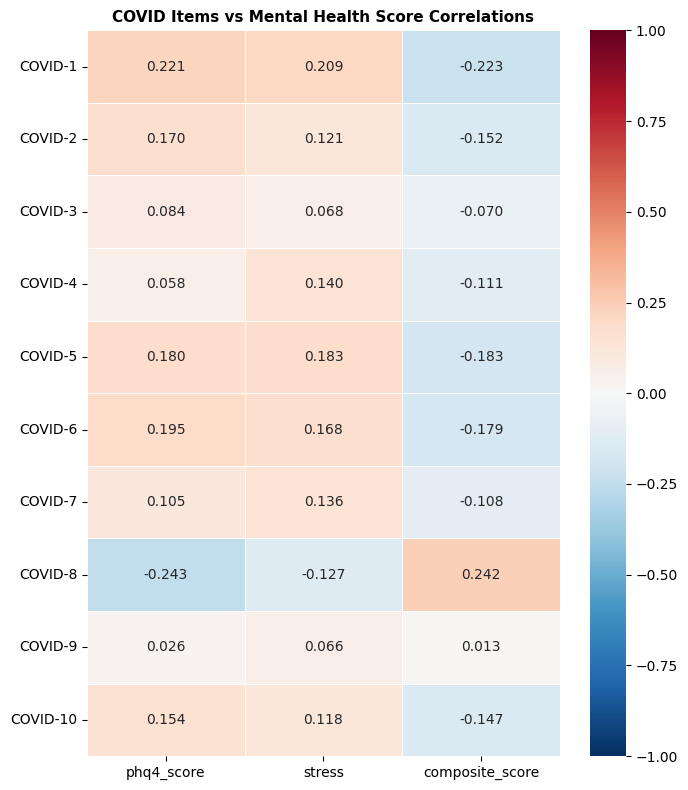

In [19]:
RESPONSE_COLS_G = ["phq4-1", "phq4-2", "phq4-3", "phq4-4",
                   "sse3-1", "sse3-2", "sse3-3", "sse3-4",
                   "phq4_score", "stress", "social_level"]

df_general_clean["has_response"] = df_general_clean[RESPONSE_COLS_G].notna().any(axis=1)
df_g_completed = df_general_clean[df_general_clean["has_response"]].copy()

# Compute composite on general_ema for comparison
df_g_completed["sse3-1_r"] = 6 - df_g_completed["sse3-1"]
sse_cols = ["sse3-1_r", "sse3-2", "sse3-3", "sse3-4"]
df_g_completed["sse_score"] = df_g_completed[sse_cols].sum(axis=1, min_count=1)

def normalize_instrument(series, min_val, max_val, invert):
    n = (series - min_val) / (max_val - min_val)
    n = n.clip(0, 1)
    return 1 - n if invert else n

ranges = {
    "phq4_score":   (0,  12, True),
    "stress":       (1,  5,  True),
    "social_level": (1,  5,  False),
    "sse_score":    (4,  20, False),
}

norm_cols = []
for col, (mn, mx, inv) in ranges.items():
    nc = f"norm_{col}"
    df_g_completed[nc] = normalize_instrument(df_g_completed[col], mn, mx, inv)
    norm_cols.append(nc)

df_g_completed["composite_score"] = df_g_completed[norm_cols].mean(axis=1, skipna=False) * 100

# Join on (uid, year_week) - same-week overlap
g_weekly = (
    df_g_completed.groupby(["uid", "year_week"])[
        ["phq4_score", "stress", "composite_score"]
    ].mean().reset_index()
)

covid_weekly_scores = (
    completed_covid.groupby(["uid", "year_week"])[COVID_ITEMS]
    .mean().reset_index()
)

merged = g_weekly.merge(covid_weekly_scores, on=["uid", "year_week"])

print(f"Weeks with both general_ema and COVID EMA responses: {len(merged):,}")
print(f"Students represented in overlap                    : {merged['uid'].nunique()}")

if len(merged) > 0:
    target_cols = ["phq4_score", "stress", "composite_score"]
    corr = merged[COVID_ITEMS + target_cols].corr().loc[COVID_ITEMS, target_cols].round(3)
    print(f"\nCorrelation between COVID items and mental health scores:")
    print(corr)

    fig, ax = plt.subplots(figsize=(7, 8))
    sns.heatmap(
        corr, annot=True, fmt=".3f", cmap="RdBu_r",
        center=0, vmin=-1, vmax=1, ax=ax,
        linewidths=0.5
    )
    ax.set_title("COVID Items vs Mental Health Score Correlations", fontsize=11, fontweight="bold")
    plt.tight_layout()
    plt.savefig("../../outputs/figures/covid_vs_mental_health_correlation.png",
                dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("No overlapping weeks found - COVID and general_ema surveys did not co-occur.")

### Temporal Trend of COVID Concern

COVID concern likely changed over the pandemic period as restrictions,
case numbers, and societal responses evolved. A feature that trends
strongly over time requires careful handling in the train/test split
to avoid data leakage - the model must not see future COVID context
when predicting past weeks.

Produces a COVID trends diagram in output/figures.

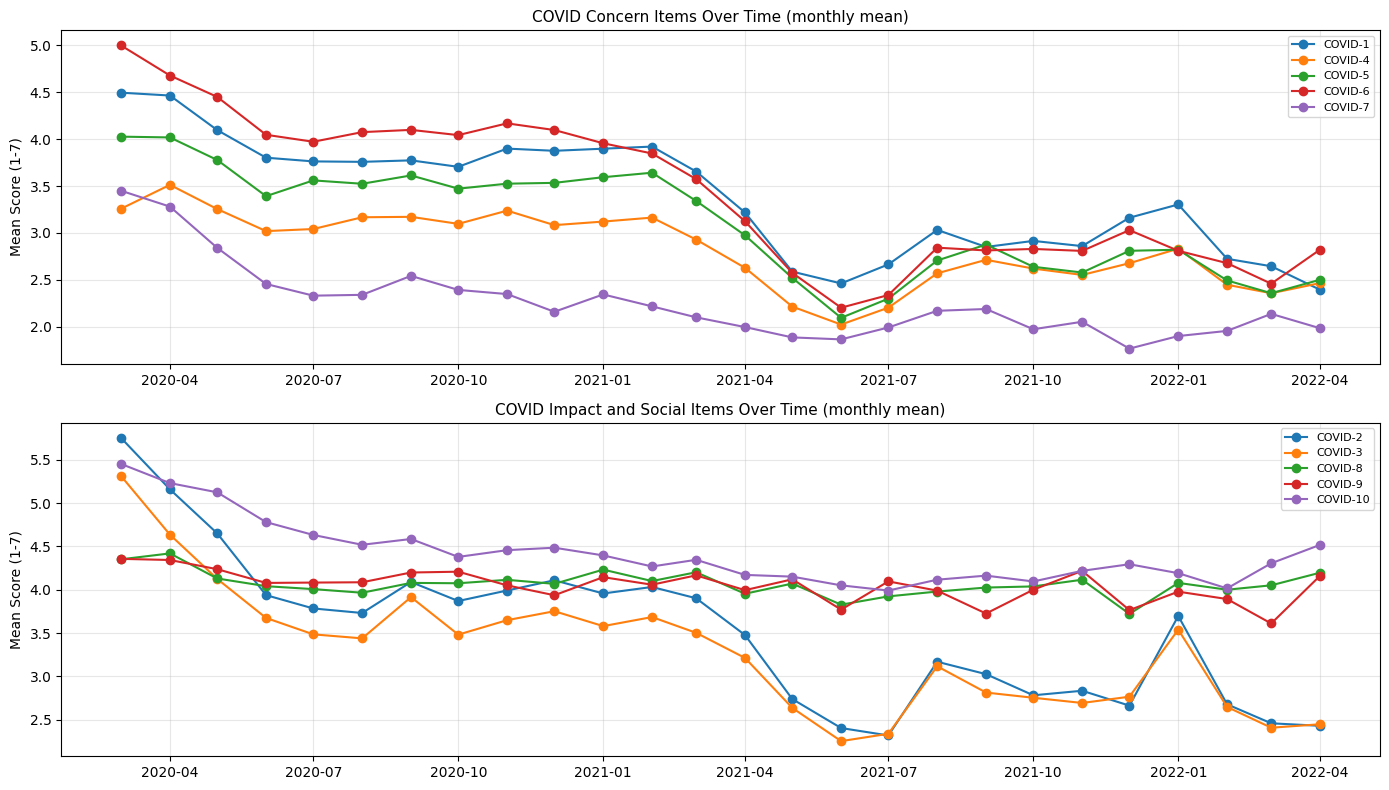

In [20]:
# Monthly average of each COVID item over time
completed_covid["month"] = completed_covid["date"].dt.to_period("M")

monthly_avg = (
    completed_covid.groupby("month")[COVID_ITEMS]
    .mean()
    .reset_index()
)
monthly_avg["month_dt"] = monthly_avg["month"].dt.to_timestamp()

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Concern items (negative)
concern_items = ["COVID-1", "COVID-4", "COVID-5", "COVID-6", "COVID-7"]
for col in concern_items:
    axes[0].plot(monthly_avg["month_dt"], monthly_avg[col], marker="o",
                 linewidth=1.5, label=col)
axes[0].set_title("COVID Concern Items Over Time (monthly mean)", fontsize=11)
axes[0].set_ylabel("Mean Score (1-7)")
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3)

# Impact and social items
other_items = ["COVID-2", "COVID-3", "COVID-8", "COVID-9", "COVID-10"]
for col in other_items:
    axes[1].plot(monthly_avg["month_dt"], monthly_avg[col], marker="o",
                 linewidth=1.5, label=col)
axes[1].set_title("COVID Impact and Social Items Over Time (monthly mean)", fontsize=11)
axes[1].set_ylabel("Mean Score (1-7)")
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("../../outputs/figures/covid_temporal_trends.png", dpi=150, bbox_inches="tight")
plt.show()